In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

#Importing all 3 files, grouping them to see each contributor's total contribution, and sorting them in descending order.
#Replace csv names with the names of your files. 
df1 = pd.read_csv('Cleo Fields.csv')
df1 = df1.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df1 = df1.sort_values(by='contribution_receipt_amount', ascending=False)

df2 = pd.read_csv('Henry Cuellar.csv')
df2 = df2.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df2 = df2.sort_values(by='contribution_receipt_amount', ascending=False)

df3 = pd.read_csv('George Latimer.csv')
df3 = df3.groupby('contributor_name')['contribution_receipt_amount'].sum().reset_index()
df3 = df3.sort_values(by='contribution_receipt_amount', ascending=False)

/var/folders/kd/vbb_z2sx1v77lx3gryhm1l680000gn/T/ipykernel_80698/3753449667.py:15: DtypeWarning: Columns (40,41,42,43,44,47,48,49,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('George Latimer.csv')


In [10]:
df1.head(10)


,contributor_name,contribution_receipt_amount
3,ACTBLUE,29800.00
485,SMOKE BEND ASSOCIATES LLC FEDERAL POLITICAL AC...,11582.80
444,REGIONS BANK,10099.99
564,WHO DAT PAC,10000.00
132,CRESCENT RIVER PORT PILOTS ASSOCIATION FEDERAL...,10000.00
332,"LEWIS, GARRY",9900.00
435,"PRICE, TEDDY",8000.00
429,POPS PLAZA LLC,6600.00
89,"CARMOUCH, DONALD T",6600.00
446,"REIS, C SCOTT",6600.00


In [11]:
df2.head(10)


,contributor_name,contribution_receipt_amount
6,ACTBLUE,432175.0
243,DEMOCRACY ENGINE LLC,145850.0
62,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE PAC,43850.0
78,AMERIPAC: THE FUND FOR A GREATER AMERICA,30857.0
222,"CUELLAR, HENRY",18000.0
618,MILLER & CHEVALIER CHARTERED,14503.3
192,CLIFFORD CHANCE LLP,14053.3
342,"GARIBAY, SOPHIA S.",13200.0
340,"GARIBAY, RUBEN",13200.0
697,NO LABELS PROBLEM SOLVERS POLITICAL ACTION COM...,13000.0


In [12]:
df3.head(10)

,contributor_name,contribution_receipt_amount
94,AMERICAN ISRAEL PUBLIC AFFAIRS COMMITTEE POLIT...,2716493.55
28,ACTBLUE,2374401.46
840,"DEMOCRACY ENGINE, INC., PAC",510059.45
3162,NORPAC,65000.00
3100,NATIONAL ELEVATOR CONSTRUCTORS PAC/ INTN'L UN...,15000.00
1945,"INTERNATIONAL ASSOCIATION OF SHEET METAL, AIR,...",15000.00
568,CARPENTERS LEGISLATIVE IMPROVEMENT COMMITTEE U...,15000.00
89,AMERICAN FEDERATION OF STATE COUNTY & MUNICIPA...,15000.00
154,"ATLAS AIR WORLDWIDE HOLDINGS, INC. POLITICAL A...",13000.00
999,ENGINEERS POLITICAL EDUCATION COMMITTEE (EPEC)...,12500.00


### LOW DEMOCRATIC

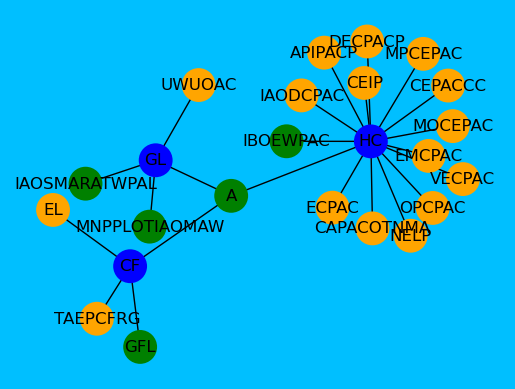

In [ ]:
members = [
    {
        "name": "Cleo Fields",
        "fossil": [
            "THE AMERICAN ELECTRIC POWER COMMITTEE FOR RESPONSIBLE GOVERNMENT",
            "ENERGY LLC"
        ],
        "green": [
            "ACTBLUE",
            "GREEN FOR LOUISIANA"
        ]
    },
    {
        "name": "Henry Cuellar",
        "fossil": [
            "VALERO ENERGY CORPORATION POLITICAL ACTION COMMITTEE",
            "OCCIDENTAL PETROLEUM CORPORATION POLITICAL ACTION COMMITTEE",
            "AMERICAN PETROLEUM INSTITUTE POLITICAL ACTION COMMITTEE (API PAC)",
            "EXXON MOBIL CORPORATION-MOBIL POLITICAL ACTION COMMITTEE"
        ],
        "green": [
            "ACTBLUE",
            "INTERNATIONAL BROTHERHOOD OF ELECTRICAL WORKERS POLITICAL ACTION COMMITTEE"
        ]
    },
    {
        "name": "George Latimer",
        "fossil": [
            "UTILITY WORKERS UNION OF AMERICA COPE"
        ],
        "green": [
            "ACTBLUE",
            "INTERNATIONAL ASSOCIATION OF SHEET METAL, AIR, RAIL AND TRANSPORTATION WORKERS POLITICAL ACTION LEAGUE",
            "MACHINISTS NON PARTISAN POLITICAL LEAGUE OF THE INTERNATIONAL ASSOCIATION OF MACHINISTS & AEROSPACE WORKERS"
        ]
    }
]

Gs = [nx.Graph(), nx.Graph(), nx.Graph()]

dfs = [df1, df2, df3]

for i, (df, m) in enumerate(zip(dfs, members)):
    df["stance"] = "gray"
    df["target"] = m["name"]

    # Play around with these colors if you'd like, defaults are orange and green.
    df.loc[df["contributor_name"].isin(m["fossil"]), "stance"] = "orange"
    df.loc[df["contributor_name"].isin(m["green"]), "stance"] = "green"

    Gs[i] = nx.from_pandas_edgelist(
        df[df["contributor_name"].isin(m["fossil"] + m["green"])],
        source="contributor_name",
        target="target",
        edge_attr=["stance"]
    )
    


    for _, row in df.iterrows():
        if row["contributor_name"] in Gs[i].nodes:
            Gs[i].nodes[row["contributor_name"]]["color"] = row["stance"]

    # If working with Democrats, change to "skyblue"
    Gs[i].nodes[m["name"]]["color"] = "blue"

G1 = Gs[0]
G1.add_nodes_from(Gs[1].nodes(data=True))
G1.add_nodes_from(Gs[2].nodes(data=True))
G1.add_edges_from(Gs[1].edges(data=True))
G1.add_edges_from(Gs[2].edges(data=True))

key = []
labels = {}
for n in G1.nodes():
    parts = n.split() 
    letters = [p[0] for p in parts if p[0].isalpha()]
    labels[n] = "".join(letters)
    key.append({labels[n] : n})


node_colors = [G1.nodes[n].get("color", "gray") for n in G1.nodes()]

fig, ax = plt.subplots()
pos = nx.spring_layout(G1, k=1, iterations=100)
nx.draw(G1, pos=pos, with_labels=True, labels=labels, node_color=node_colors, node_size=500, edge_color='black', linewidths=2)
ax.axis('off')
#You can change the background color here. 
fig.set_facecolor('deepskyblue')
plt.show()

In [14]:
print("Key: ")
for item in key:
    for k, v in item.items( ):
        print(f"{k} = {v}") 

Key: 
A = ACTBLUE
CF = Cleo Fields
GFL = GREEN FOR LOUISIANA
EL = ENERGY LLC
TAEPCFRG = THE AMERICAN ELECTRIC POWER COMMITTEE FOR RESPONSIBLE GOVERNMENT
HC = Henry Cuellar
APIPACP = AMERICAN PETROLEUM INSTITUTE POLITICAL ACTION COMMITTEE (API PAC)
CEIP = CHENIERE ENERGY, INC. PAC
MOCEPAC = MARATHON OIL COMPANY EMPLOYEES POLITICAL ACTION COMMITTEE (MEPAC)
EMCPAC = EXXON MOBIL CORPORATION-MOBIL POLITICAL ACTION COMMITTEE
DECPACP = DEVON ENERGY CORPORATION POLITICAL ACTION COMMITTEE (DEC PAC)
OPCPAC = OCCIDENTAL PETROLEUM CORPORATION POLITICAL ACTION COMMITTEE
NELP = NUSTAR ENERGY L.P. (NUSTAR PAC)
MPCEPAC = MARATHON PETROLEUM CORPORATION EMPLOYEES POLITICAL ACTION COMMITTEE (MPAC)
IBOEWPAC = INTERNATIONAL BROTHERHOOD OF ELECTRICAL WORKERS POLITICAL ACTION COMMITTEE
VECPAC = VALERO ENERGY CORPORATION POLITICAL ACTION COMMITTEE
ECPAC = ENTERGY CORPORATION POLITICAL ACTION COMMITTEE (ENPAC)
CEPACCC = CHEVRON EMPLOYEES POLITICAL ACTION COMMITTEE - CHEVRON CORPORATION
CAPACOTNMA = COALPAC, A 